# E-commerce Recommendation System EDA

本 Notebook 包含推薦系統的探索性資料分析 (Exploratory Data Analysis)，將分析使用者購買行為、商品長尾效應、行為漏斗以及時間趨勢。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 設定中文字型與視覺樣式
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'PingFang HK', 'SimHei'] # 支援多種作業系統的中文字型
plt.rcParams['axes.unicode_minus'] = False

shop_id = "RZSHERLBqjPGOUFO01RYew=="

print("Loading orders data...")
train_orders = pd.read_csv(f"orders_train_{shop_id}.csv", low_memory=False)
test_orders = pd.read_csv(f"orders_test_{shop_id}.csv", low_memory=False)

train_orders['OrderDateTime'] = pd.to_datetime(train_orders['OrderDateTime'])
test_orders['OrderDateTime'] = pd.to_datetime(test_orders['OrderDateTime'])
print("Data loaded successfully.")

Loading orders data...
Data loaded successfully.


## 1. 購買行為分析 (Purchase Behavior Analysis)
探討每位使用者在 Train / Test 期間平均購買的商品數量。

【訓練集 Train】
 - 總用戶數: 378,385
 - 平均購買商品數: 4.71
 - 購買商品數中位數: 3.00

【測試集 Test】
 - 總用戶數: 116,129
 - 平均購買商品數: 3.92
 - 購買商品數中位數: 2.00


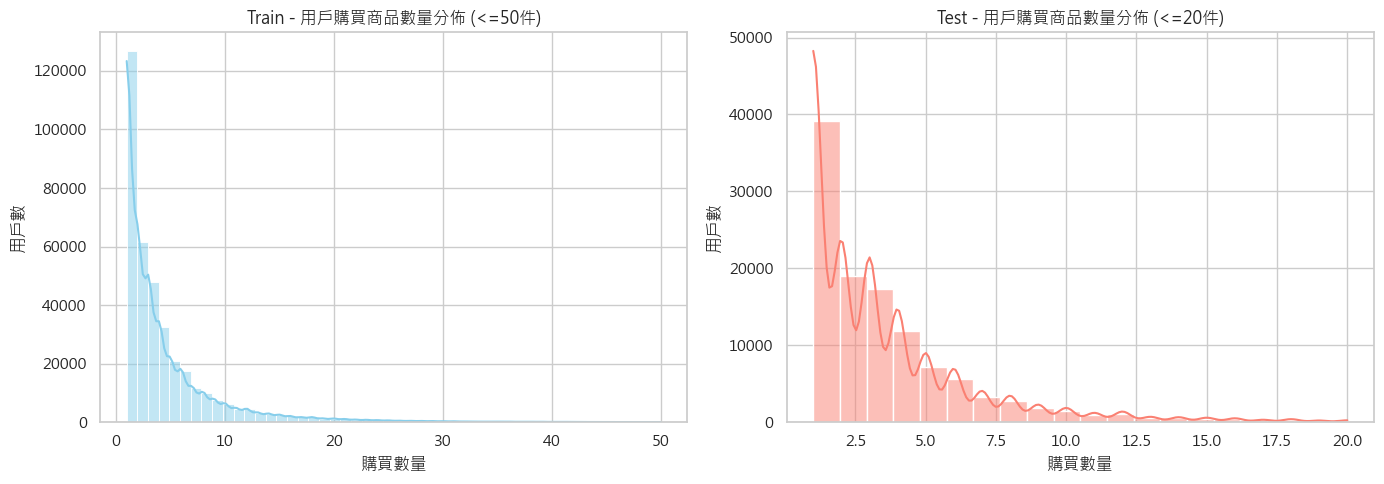

In [2]:
train_user_stats = train_orders.groupby("ShopMemberId").size()
test_user_stats = test_orders.groupby("ShopMemberId").size()

print(f"【訓練集 Train】")
print(f" - 總用戶數: {len(train_user_stats):,}")
print(f" - 平均購買商品數: {train_user_stats.mean():.2f}")
print(f" - 購買商品數中位數: {train_user_stats.median():.2f}\n")

print(f"【測試集 Test】")
print(f" - 總用戶數: {len(test_user_stats):,}")
print(f" - 平均購買商品數: {test_user_stats.mean():.2f}")
print(f" - 購買商品數中位數: {test_user_stats.median():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_user_stats[train_user_stats <= 50], bins=50, ax=axes[0], kde=True, color='skyblue')
axes[0].set_title('Train - 用戶購買商品數量分佈 (<=50件)')
axes[0].set_xlabel('購買數量')
axes[0].set_ylabel('用戶數')

sns.histplot(test_user_stats[test_user_stats <= 20], bins=20, ax=axes[1], kde=True, color='salmon')
axes[1].set_title('Test - 用戶購買商品數量分佈 (<=20件)')
axes[1].set_xlabel('購買數量')
axes[1].set_ylabel('用戶數')

plt.tight_layout()
plt.show()

## 2. 商品長尾效應分析 (Product Long-tail Effect)
分析少數熱門商品佔據整體銷售額的比例（80/20 法則）。

總商品數: 916
前 20% 熱門商品佔總銷售量的比例: 87.83%


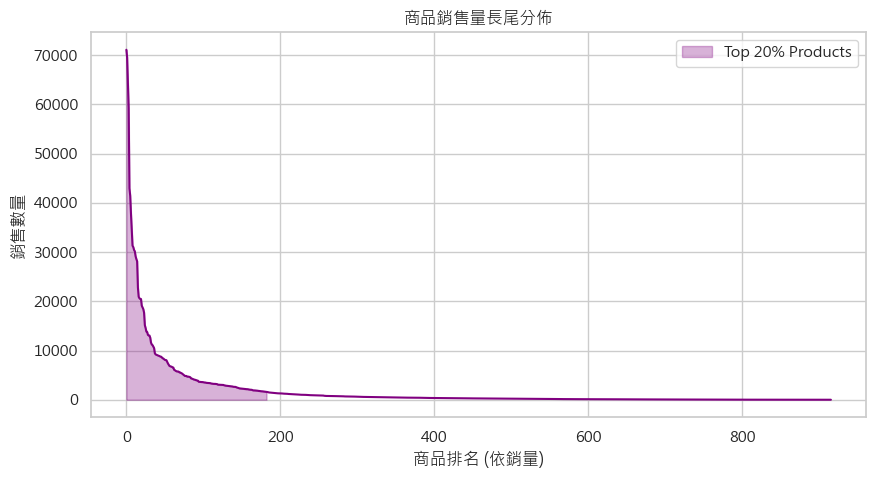

In [4]:
product_stats = train_orders.groupby("OuterProductSkuCode").size().sort_values(ascending=False)

print(f"總商品數: {len(product_stats):,}")
top_20_pct_idx = int(len(product_stats) * 0.2)
top_20_sales = product_stats.head(top_20_pct_idx).sum()
total_sales = product_stats.sum()
print(f"前 20% 熱門商品佔總銷售量的比例: {top_20_sales / total_sales:.2%}")

plt.figure(figsize=(10, 5))
plt.plot(range(len(product_stats)), product_stats.values, color='purple')
plt.fill_between(range(top_20_pct_idx), product_stats.values[:top_20_pct_idx], color='purple', alpha=0.3, label='Top 20% Products')
plt.title('商品銷售量長尾分佈')
plt.xlabel('商品排名 (依銷量)')
plt.ylabel('銷售數量')
plt.legend()
plt.show()

## 3. 訂單時間趨勢 (Time Series Trend)
觀察每日的訂單變化，確認 Train / Test 切分的連續性與季節性特徵。

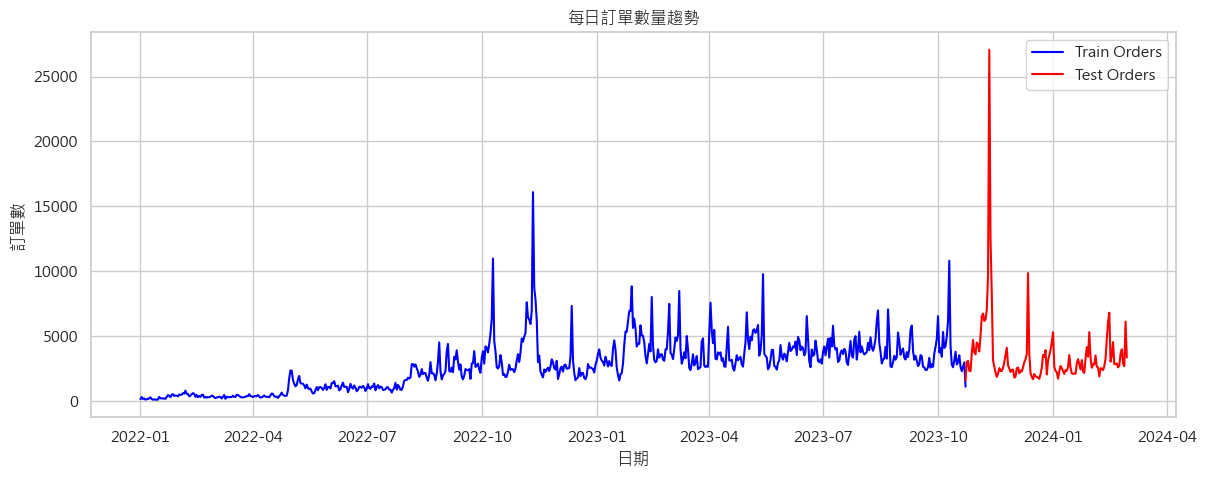

In [5]:
daily_train = train_orders.set_index('OrderDateTime').resample('D').size()
daily_test = test_orders.set_index('OrderDateTime').resample('D').size()

plt.figure(figsize=(14, 5))
plt.plot(daily_train.index, daily_train.values, label='Train Orders', color='blue')
plt.plot(daily_test.index, daily_test.values, label='Test Orders', color='red')
plt.title('每日訂單數量趨勢')
plt.xlabel('日期')
plt.ylabel('訂單數')
plt.legend()
plt.show()